# Hipótese 1 — Caso Monark

## Pergunta
No episódio de cancelamento do Monark, a rede evolui de uma distribuição mais plural para uma dinâmica de convergência vitimária?

## Sinais esperados
1. surgem líderes acusatórios;
2. a atenção converge para a vítima;
3. a estrutura comunitária enfraquece;
4. a vítima fica isolada;
5. opcionalmente, surgem vítimas substitutas, instituições reforçadoras e uma minoria cética.

## Estratégia
Vou usar janelas temporais para medir:
- concentração (`indeg_centralization`, `top1_share_in`);
- comunidade (`modularity`, `intercommunity_ratio`);
- isolamento da vítima (`ego_density`, `ego_reciprocity`, e, se existir, `avg_dist`);
- intensidade do episódio (`n_edges` e/ou `volume`).

Este notebook foi preparado para rodar **localmente** e no **Google Colab**. No Colab, preencha `REPO_URL` e `REPO_NAME` na célula seguinte. As **métricas temporais** usam o arquivo de 3h e todos os arquivos de 6h do caso Monark. Os **snapshots visuais** (grafos GEXF) usam apenas os arquivos de 6h para manter comparabilidade entre as janelas.

In [55]:
from pathlib import Path
import os
import sys
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from IPython.display import display, Markdown, Image

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

IN_COLAB = "google.colab" in sys.modules

# Preencher antes da entrega, se for usar no Colab abrindo a partir do GitHub
REPO_URL = "COLE_AQUI_A_URL_PUBLICA_DO_REPOSITORIO"
REPO_NAME = "COLE_AQUI_O_NOME_DO_REPOSITORIO"

if IN_COLAB:
    repo_path = Path("/content") / REPO_NAME
    if REPO_URL.startswith("COLE_AQUI"):
        print("ATENÇÃO: preencha REPO_URL e REPO_NAME para rodar no Colab.")
    else:
        if not repo_path.exists():
            subprocess.run(["git", "clone", REPO_URL, str(repo_path)], check=True)
        os.chdir(repo_path)

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pandas", "matplotlib", "networkx", "python-louvain"],
        check=True
    )

REPO_ROOT = Path.cwd()
CASE = "monark"
VICTIM = "@monark"

OUT_BASE = REPO_ROOT / "reports" / "h1_monark"
OUT_WINDOWED = OUT_BASE / "windowed"
OUT_ISO = OUT_BASE / "isolation"
OUT_GEXF = OUT_BASE / "gexf"
OUT_PLOTS = OUT_BASE / "plots"

for p in [OUT_BASE, OUT_WINDOWED, OUT_ISO, OUT_GEXF, OUT_PLOTS]:
    p.mkdir(parents=True, exist_ok=True)

print("IN_COLAB =", IN_COLAB)
print("REPO_ROOT =", REPO_ROOT)

IN_COLAB = False
REPO_ROOT = c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi


In [56]:
CANDIDATE_DIRS = [
    REPO_ROOT / "data" / "processed" / "monark",
]

files_3h = []
files_6h = []
DATA_DIR = None

for d in CANDIDATE_DIRS:
    if d.exists():
        found_3h = sorted(d.rglob("monark_3h_*.jsonl"))
        found_6h = sorted(d.rglob("monark_6h_*.jsonl"))
        if found_3h or found_6h:
            files_3h = found_3h
            files_6h = found_6h
            DATA_DIR = d
            break

assert files_3h or files_6h, "Nenhum arquivo JSONL do caso Monark foi encontrado no repositório."

print("Base usada:", DATA_DIR)
print(f"Total de arquivos 3h encontrados: {len(files_3h)}")
for i, f in enumerate(files_3h):
    print(f"3h {i:02d} - {f}")

print(f"\nTotal de arquivos 6h encontrados: {len(files_6h)}")
for i, f in enumerate(files_6h):
    print(f"6h {i:02d} - {f}")


Base usada: c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark
Total de arquivos 3h encontrados: 1
3h 00 - c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_3h_2022-02-08_21-00_23-59.jsonl

Total de arquivos 6h encontrados: 4
6h 00 - c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_00-00_05-59.jsonl
6h 01 - c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_06-00_11-59.jsonl
6h 02 - c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_12-00_17-59.jsonl
6h 03 - c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_18-00_23-59.jsonl


In [57]:
selected_files_metrics = sorted(files_3h + files_6h, key=lambda p: p.name)
selected_files_gexf = sorted(files_6h, key=lambda p: p.name)

print("Arquivos selecionados para MÉTRICAS:")
for f in selected_files_metrics:
    print("-", f)

print(f"\nTotal para métricas: {len(selected_files_metrics)}")

print("\nArquivos selecionados para GEXF / snapshots:")
for f in selected_files_gexf:
    print("-", f)

print(f"\nTotal para GEXF: {len(selected_files_gexf)}")

assert len(selected_files_metrics) > 0, "A lista de arquivos para métricas está vazia."
assert len(selected_files_gexf) > 0, "A lista de arquivos para GEXF está vazia."

Arquivos selecionados para MÉTRICAS:
- c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_3h_2022-02-08_21-00_23-59.jsonl
- c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_00-00_05-59.jsonl
- c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_06-00_11-59.jsonl
- c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_12-00_17-59.jsonl
- c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_18-00_23-59.jsonl

Total para métricas: 5

Arquivos selecionados para GEXF / snapshots:
- c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_00-00_05-59.jsonl
- c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_06-00_11-59.jsonl
- c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_20

In [58]:
script_path = REPO_ROOT / "src" / "windowed_metrics.py"
assert script_path.exists(), f"Script não encontrado: {script_path}"

cmd = [
    sys.executable,
    str(script_path),
    "--jsonl",
    *[str(f) for f in selected_files_metrics],
    "--victim", VICTIM,
    "--outdir", str(OUT_WINDOWED),
    "--freq", "H",
    "--community", "louvain",
    "--plots",
]

print("Comando:")
print(" ".join(cmd))

subprocess.run(cmd, check=True)

Comando:
c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\.venv\Scripts\python.exe c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\scripts\windowed_metrics.py --jsonl c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_3h_2022-02-08_21-00_23-59.jsonl c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_00-00_05-59.jsonl c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_06-00_11-59.jsonl c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_12-00_17-59.jsonl c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\data\processed\monark\monark_6h_2022-02-09_18-00_23-59.jsonl --victim @monark --outdir c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\outputs\h1_monark\windowed --freq H --community louvain --plots


CompletedProcess(args=['c:\\Users\\Paes1\\NETLOGO\\scapegoat_pipeline_gephi\\.venv\\Scripts\\python.exe', 'c:\\Users\\Paes1\\NETLOGO\\scapegoat_pipeline_gephi\\scripts\\windowed_metrics.py', '--jsonl', 'c:\\Users\\Paes1\\NETLOGO\\scapegoat_pipeline_gephi\\mvp\\data\\processed\\monark\\monark_3h_2022-02-08_21-00_23-59.jsonl', 'c:\\Users\\Paes1\\NETLOGO\\scapegoat_pipeline_gephi\\mvp\\data\\processed\\monark\\monark_6h_2022-02-09_00-00_05-59.jsonl', 'c:\\Users\\Paes1\\NETLOGO\\scapegoat_pipeline_gephi\\mvp\\data\\processed\\monark\\monark_6h_2022-02-09_06-00_11-59.jsonl', 'c:\\Users\\Paes1\\NETLOGO\\scapegoat_pipeline_gephi\\mvp\\data\\processed\\monark\\monark_6h_2022-02-09_12-00_17-59.jsonl', 'c:\\Users\\Paes1\\NETLOGO\\scapegoat_pipeline_gephi\\mvp\\data\\processed\\monark\\monark_6h_2022-02-09_18-00_23-59.jsonl', '--victim', '@monark', '--outdir', 'c:\\Users\\Paes1\\NETLOGO\\scapegoat_pipeline_gephi\\mvp\\outputs\\h1_monark\\windowed', '--freq', 'H', '--community', 'louvain', '--plot

In [59]:
# Gera um GEXF por JSONL de 6h (script: --input, --output)
# O script retorna 1 quando o grafo fica vazio (ex.: formato do JSONL sem arestas); seguimos e geramos os demais.
script_gexf = REPO_ROOT / "src" / "jsonl_to_gexf.py"
assert script_gexf.exists(), f"Script não encontrado: {script_gexf}"

for jf in selected_files_gexf:
    out_gexf = OUT_GEXF / (jf.stem + ".gexf")
    result = subprocess.run([
        sys.executable, str(script_gexf),
        "--input", str(jf),
        "--output", str(out_gexf),
    ], capture_output=True, text=True)
    if result.returncode == 0:
        print("Gerado:", out_gexf)
    else:
        print("Pulado (grafo vazio ou erro):", jf.name, "-", (result.stderr or result.stdout or "").strip()[:80])

Gerado: c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\outputs\h1_monark\gexf\monark_6h_2022-02-09_00-00_05-59.gexf
Gerado: c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\outputs\h1_monark\gexf\monark_6h_2022-02-09_06-00_11-59.gexf
Gerado: c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\outputs\h1_monark\gexf\monark_6h_2022-02-09_12-00_17-59.gexf
Gerado: c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\outputs\h1_monark\gexf\monark_6h_2022-02-09_18-00_23-59.gexf


In [60]:
series_path = OUT_WINDOWED / "series_windowed.csv"
assert series_path.exists(), f"Arquivo não encontrado: {series_path}"
series = pd.read_csv(series_path)

series["window_start"] = pd.to_datetime(series["window_start"], utc=True).dt.tz_convert("America/Sao_Paulo")
series["window_end"] = pd.to_datetime(series["window_end"], utc=True).dt.tz_convert("America/Sao_Paulo")

display(series.head())
print("\nColunas:")
print(series.columns.tolist())

,window_start,window_end,n_nodes,n_edges,density,indeg_centralization,top1_share_in,intercommunity_ratio,modularity,ego_n,ego_m,ego_density,ego_reciprocity
0,2022-02-08 21:00:00-03:00,2022-02-08 22:00:00-03:00,146,154,0.007274,0.139464,0.136364,NaN,NaN,22.0,21.0,0.090909,0.0
1,2022-02-08 22:00:00-03:00,2022-02-08 23:00:00-03:00,143,140,0.006895,0.164419,0.171429,NaN,NaN,25.0,24.0,0.080000,0.0
2,2022-02-08 23:00:00-03:00,2022-02-09 00:00:00-03:00,87,80,0.010692,0.131874,0.150000,NaN,NaN,13.0,12.0,0.153846,0.0
3,2022-02-09 00:00:00-03:00,2022-02-09 01:00:00-03:00,95,112,0.012542,0.117593,0.107143,NaN,NaN,13.0,12.0,0.153846,0.0
4,2022-02-09 01:00:00-03:00,2022-02-09 02:00:00-03:00,82,98,0.014755,0.162037,0.142857,NaN,NaN,15.0,14.0,0.133333,0.0



Colunas:
['window_start', 'window_end', 'n_nodes', 'n_edges', 'density', 'indeg_centralization', 'top1_share_in', 'intercommunity_ratio', 'modularity', 'ego_n', 'ego_m', 'ego_density', 'ego_reciprocity']


In [61]:
print("Número de janelas:", len(series))
print("Período:")
print(series["window_start"].min(), "->", series["window_end"].max())

display(
    series[[
        "window_start", "window_end",
        "n_nodes", "n_edges",
        "indeg_centralization", "top1_share_in",
        "modularity", "intercommunity_ratio",
        "ego_density", "ego_reciprocity"
    ]].head(10)
)

Número de janelas: 24
Período:
2022-02-08 21:00:00-03:00 -> 2022-02-09 21:00:00-03:00


,window_start,window_end,n_nodes,n_edges,indeg_centralization,top1_share_in,modularity,intercommunity_ratio,ego_density,ego_reciprocity
0,2022-02-08 21:00:00-03:00,2022-02-08 22:00:00-03:00,146,154,0.139464,0.136364,NaN,NaN,0.090909,0.0
1,2022-02-08 22:00:00-03:00,2022-02-08 23:00:00-03:00,143,140,0.164419,0.171429,NaN,NaN,0.080000,0.0
2,2022-02-08 23:00:00-03:00,2022-02-09 00:00:00-03:00,87,80,0.131874,0.150000,NaN,NaN,0.153846,0.0
3,2022-02-09 00:00:00-03:00,2022-02-09 01:00:00-03:00,95,112,0.117593,0.107143,NaN,NaN,0.153846,0.0
4,2022-02-09 01:00:00-03:00,2022-02-09 02:00:00-03:00,82,98,0.162037,0.142857,NaN,NaN,0.133333,0.0
5,2022-02-09 02:00:00-03:00,2022-02-09 03:00:00-03:00,20,14,0.076023,0.142857,NaN,NaN,0.666667,0.0
6,2022-02-09 03:00:00-03:00,2022-02-09 04:00:00-03:00,32,27,0.177419,0.222222,NaN,NaN,0.285714,0.0
7,2022-02-09 04:00:00-03:00,2022-02-09 05:00:00-03:00,7,4,0.100000,0.250000,NaN,NaN,NaN,NaN
8,2022-02-09 05:00:00-03:00,2022-02-09 06:00:00-03:00,20,24,0.105263,0.125000,NaN,NaN,0.500000,0.0
9,2022-02-09 06:00:00-03:00,2022-02-09 07:00:00-03:00,30,29,0.185961,0.206897,NaN,NaN,0.285714,0.0


In [62]:
peak_idx = series["n_edges"].idxmax()
peak_time = series.loc[peak_idx, "window_start"]
peak_edges = series.loc[peak_idx, "n_edges"]

print("Janela de pico:")
print("Tempo:", peak_time)
print("n_edges:", peak_edges)

Janela de pico:
Tempo: 2022-02-08 21:00:00-03:00
n_edges: 154


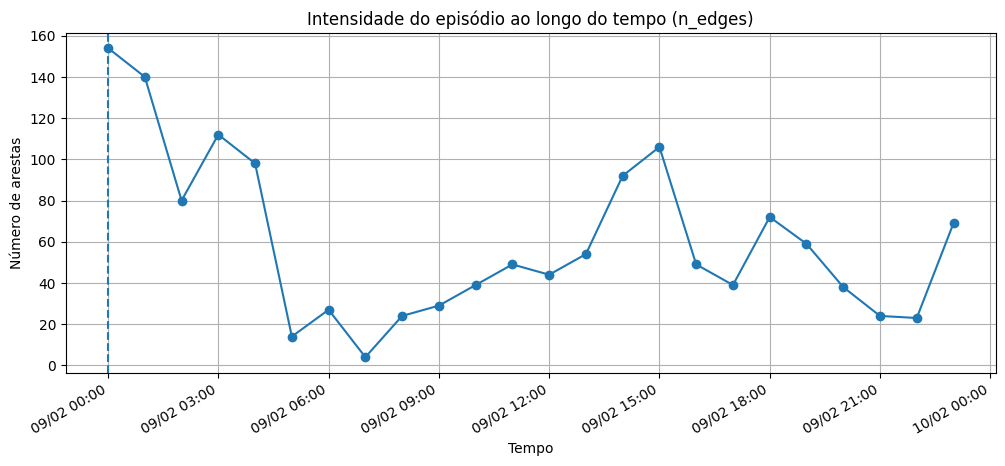

In [63]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(series["window_start"], series["n_edges"], marker="o")
ax.axvline(peak_time, linestyle="--")
ax.set_title("Intensidade do episódio ao longo do tempo (n_edges)")
ax.set_xlabel("Tempo")
ax.set_ylabel("Número de arestas")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
fig.autofmt_xdate()
plt.show()

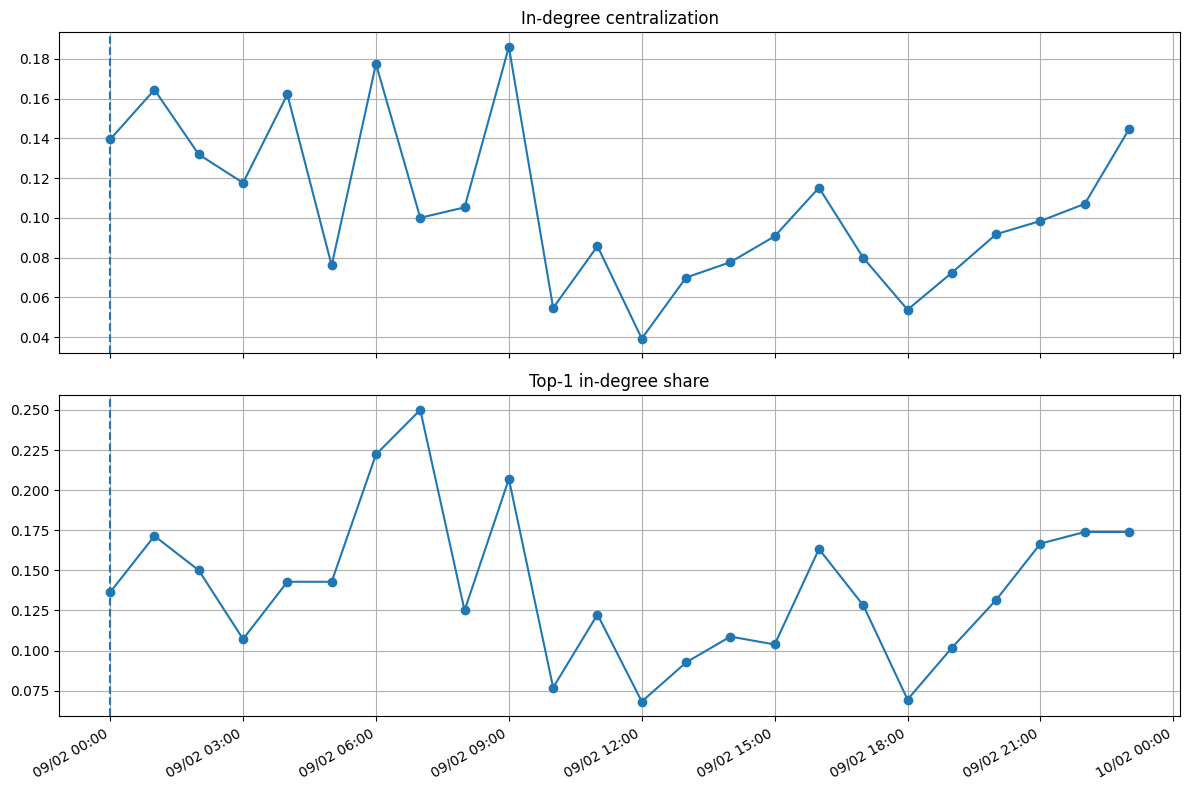

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(series["window_start"], series["indeg_centralization"], marker="o")
axes[0].axvline(peak_time, linestyle="--")
axes[0].set_title("In-degree centralization")

axes[1].plot(series["window_start"], series["top1_share_in"], marker="o")
axes[1].axvline(peak_time, linestyle="--")
axes[1].set_title("Top-1 in-degree share")

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

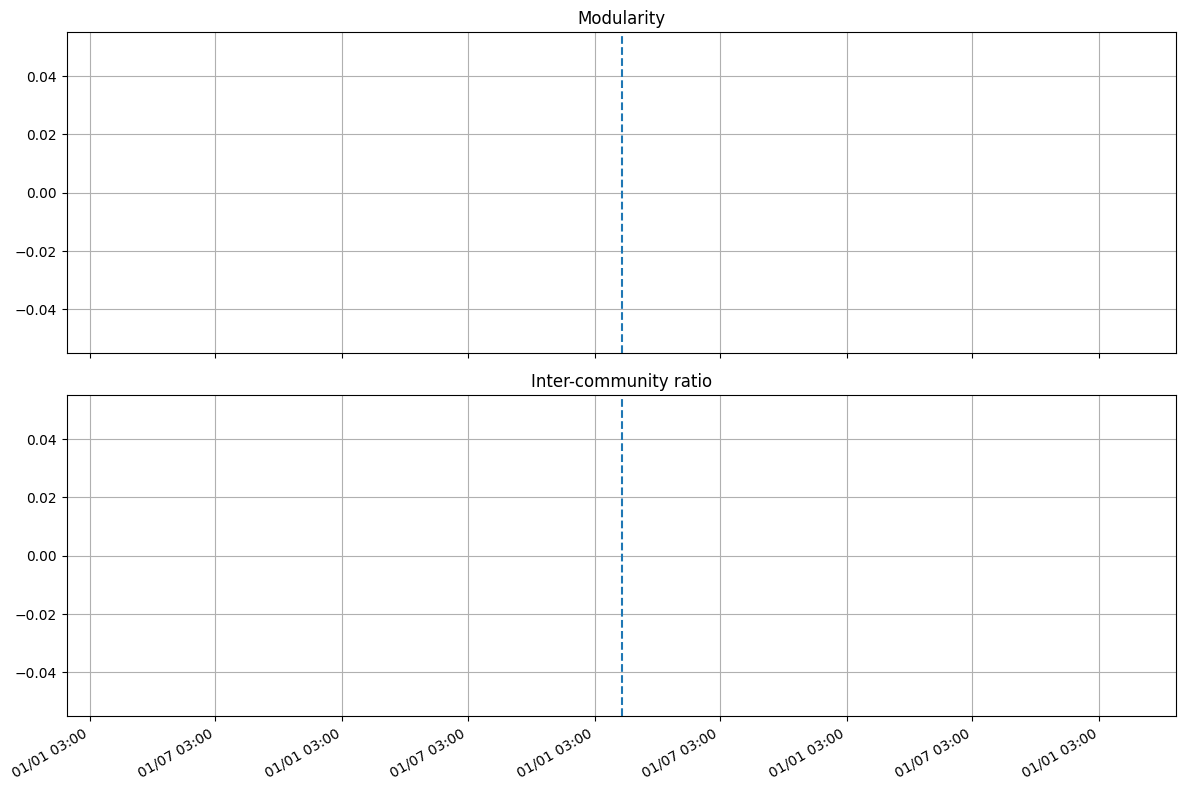

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(series["window_start"], series["modularity"], marker="o")
axes[0].axvline(peak_time, linestyle="--")
axes[0].set_title("Modularity")

axes[1].plot(series["window_start"], series["intercommunity_ratio"], marker="o")
axes[1].axvline(peak_time, linestyle="--")
axes[1].set_title("Inter-community ratio")

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

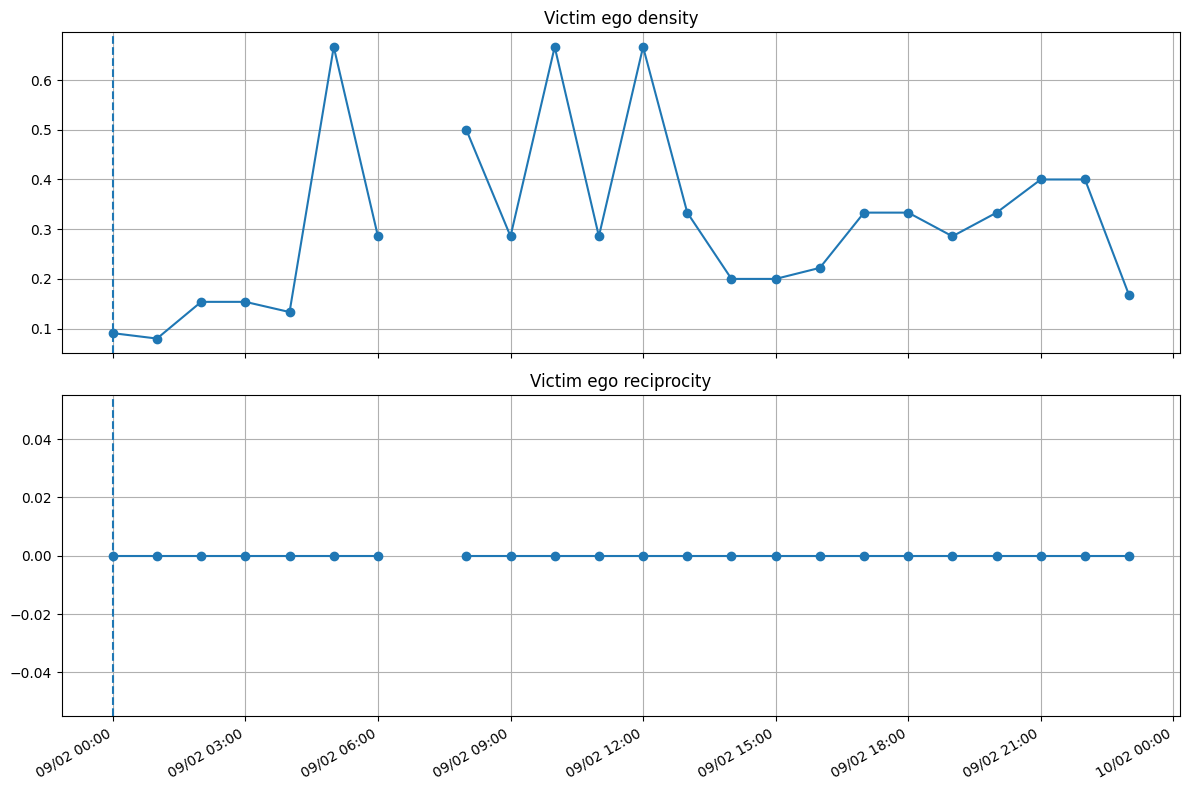

In [66]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(series["window_start"], series["ego_density"], marker="o")
axes[0].axvline(peak_time, linestyle="--")
axes[0].set_title("Victim ego density")

axes[1].plot(series["window_start"], series["ego_reciprocity"], marker="o")
axes[1].axvline(peak_time, linestyle="--")
axes[1].set_title("Victim ego reciprocity")

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [67]:
# metrics_{CASE}.csv pode ser gerado por src/ego_isolation_timeseries.py
# (exige arquivo de arestas src,dst,timestamp; CLI: --input, --case_id, --victim, --outdir)
iso_candidates = list(OUT_ISO.rglob(f"metrics_{CASE}.csv"))

if iso_candidates:
    iso_path = iso_candidates[0]
    iso = pd.read_csv(iso_path)
    iso["t"] = pd.to_datetime(iso["t"], utc=True).dt.tz_convert("America/Sao_Paulo")
    display(iso.head())
    print("Usando:", iso_path)
else:
    iso = None
    print("Nenhum metrics_monark.csv encontrado em", OUT_ISO)

Nenhum metrics_monark.csv encontrado em c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\outputs\h1_monark\isolation


In [68]:
if iso is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(iso["t"], iso["volume"], marker="o")
    axes[0].set_title("Volume")

    axes[1].plot(iso["t"], iso["avg_dist"], marker="o")
    axes[1].set_title("Average distance to victim")

    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

In [ ]:
series = series.copy().reset_index(drop=True)

peak_idx = int(series["n_edges"].idxmax())

series["phase"] = "post"
series.loc[series.index < peak_idx, "phase"] = "pre"
series.loc[series.index == peak_idx, "phase"] = "climax"

summary = series.groupby("phase")[[
    "n_edges",
    "indeg_centralization",
    "top1_share_in",
    "modularity",
    "intercommunity_ratio",
    "ego_density",
    "ego_reciprocity"
]].mean().round(4)

print("Fases presentes:", summary.index.tolist())
display(summary)

Fases presentes: ['climax', 'post']


,n_edges,indeg_centralization,top1_share_in,modularity,intercommunity_ratio,ego_density,ego_reciprocity
phase,,,,,,,
climax,154.0000,0.1395,0.1364,NaN,NaN,0.0909,0.0
post,55.8696,0.1044,0.1391,NaN,NaN,0.3221,0.0


In [72]:
def phase_value(summary_df, phase, col):
    if phase not in summary_df.index:
        return None
    return summary_df.loc[phase, col]

def compare_phases(summary_df, phase_a, phase_b, col, direction="up"):
    a = phase_value(summary_df, phase_a, col)
    b = phase_value(summary_df, phase_b, col)

    if a is None or b is None:
        return "não avaliado"

    if direction == "up":
        return a > b
    elif direction == "down":
        return a < b
    else:
        raise ValueError("direction deve ser 'up' ou 'down'")

diag = {
    "centralização sobe no clímax?": compare_phases(summary, "climax", "pre", "indeg_centralization", "up"),
    "top1_share sobe no clímax?": compare_phases(summary, "climax", "pre", "top1_share_in", "up"),
    "modularidade cai no clímax?": compare_phases(summary, "climax", "pre", "modularity", "down"),
    "ego_density cai no clímax?": compare_phases(summary, "climax", "pre", "ego_density", "down"),
    "ego_reciprocity cai no clímax?": compare_phases(summary, "climax", "pre", "ego_reciprocity", "down"),
}

diag_df = pd.DataFrame({"valor": diag})
display(diag_df)

if "pre" not in summary.index:
    print("Observação metodológica: não existe fase 'pre' neste recorte; a primeira janela já coincide com o pico.")

,valor
centralização sobe no clímax?,não avaliado
top1_share sobe no clímax?,não avaliado
modularidade cai no clímax?,não avaliado
ego_density cai no clímax?,não avaliado
ego_reciprocity cai no clímax?,não avaliado


Observação metodológica: não existe fase 'pre' neste recorte; a primeira janela já coincide com o pico.


### centralization_over_time.png

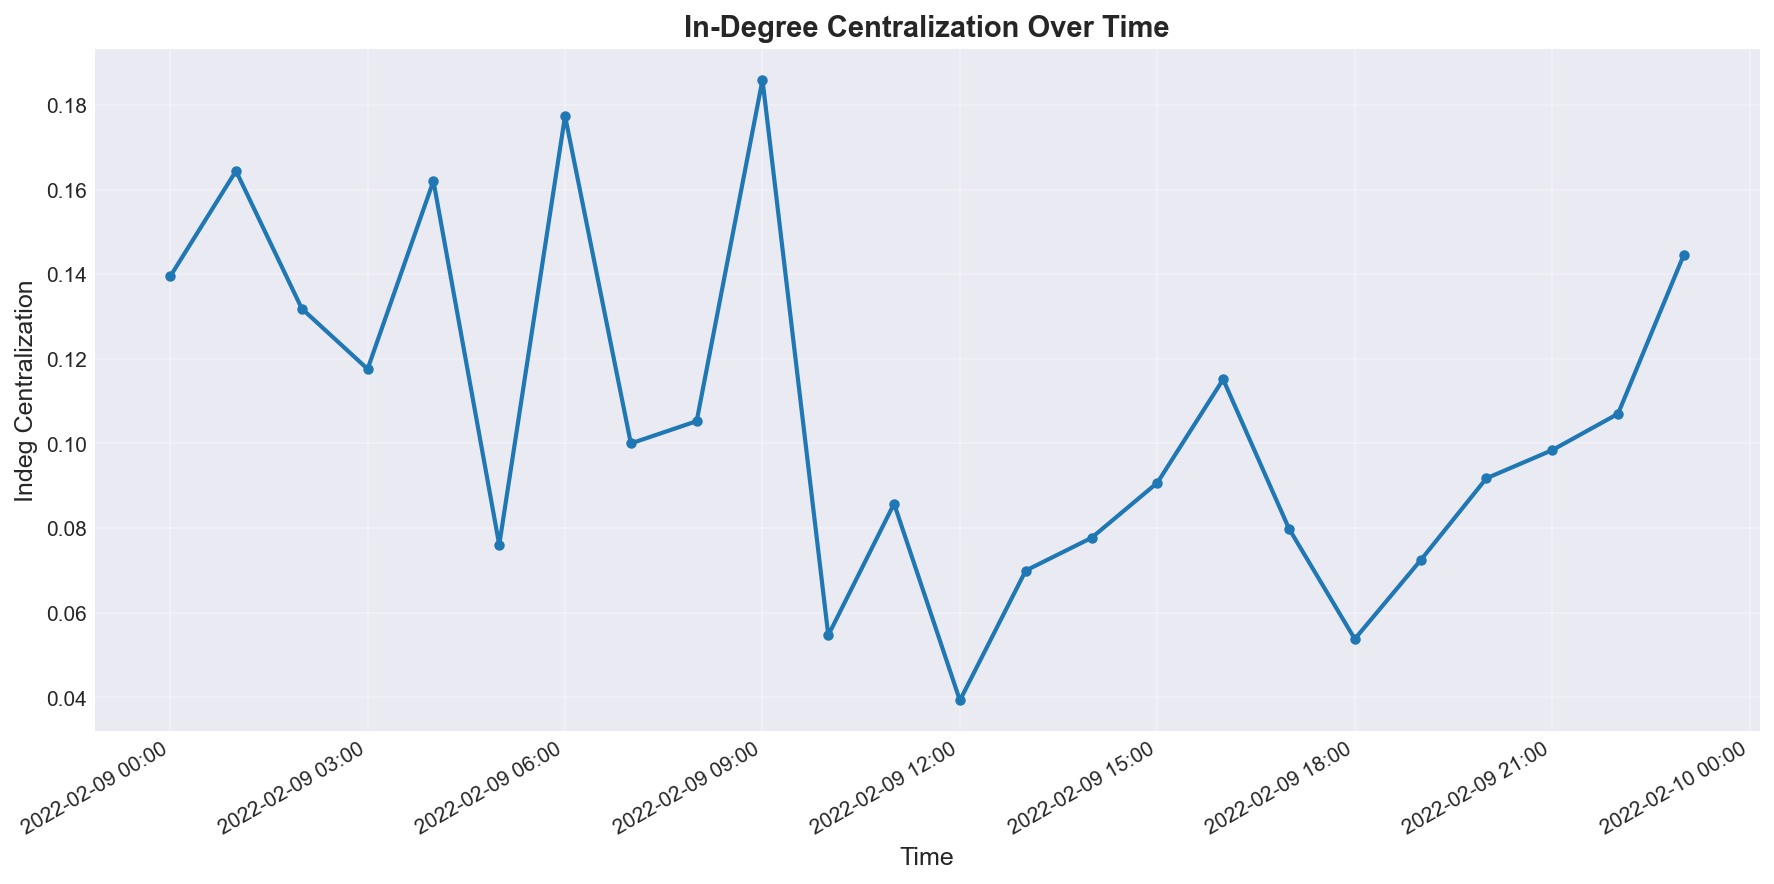

### top1_share_over_time.png

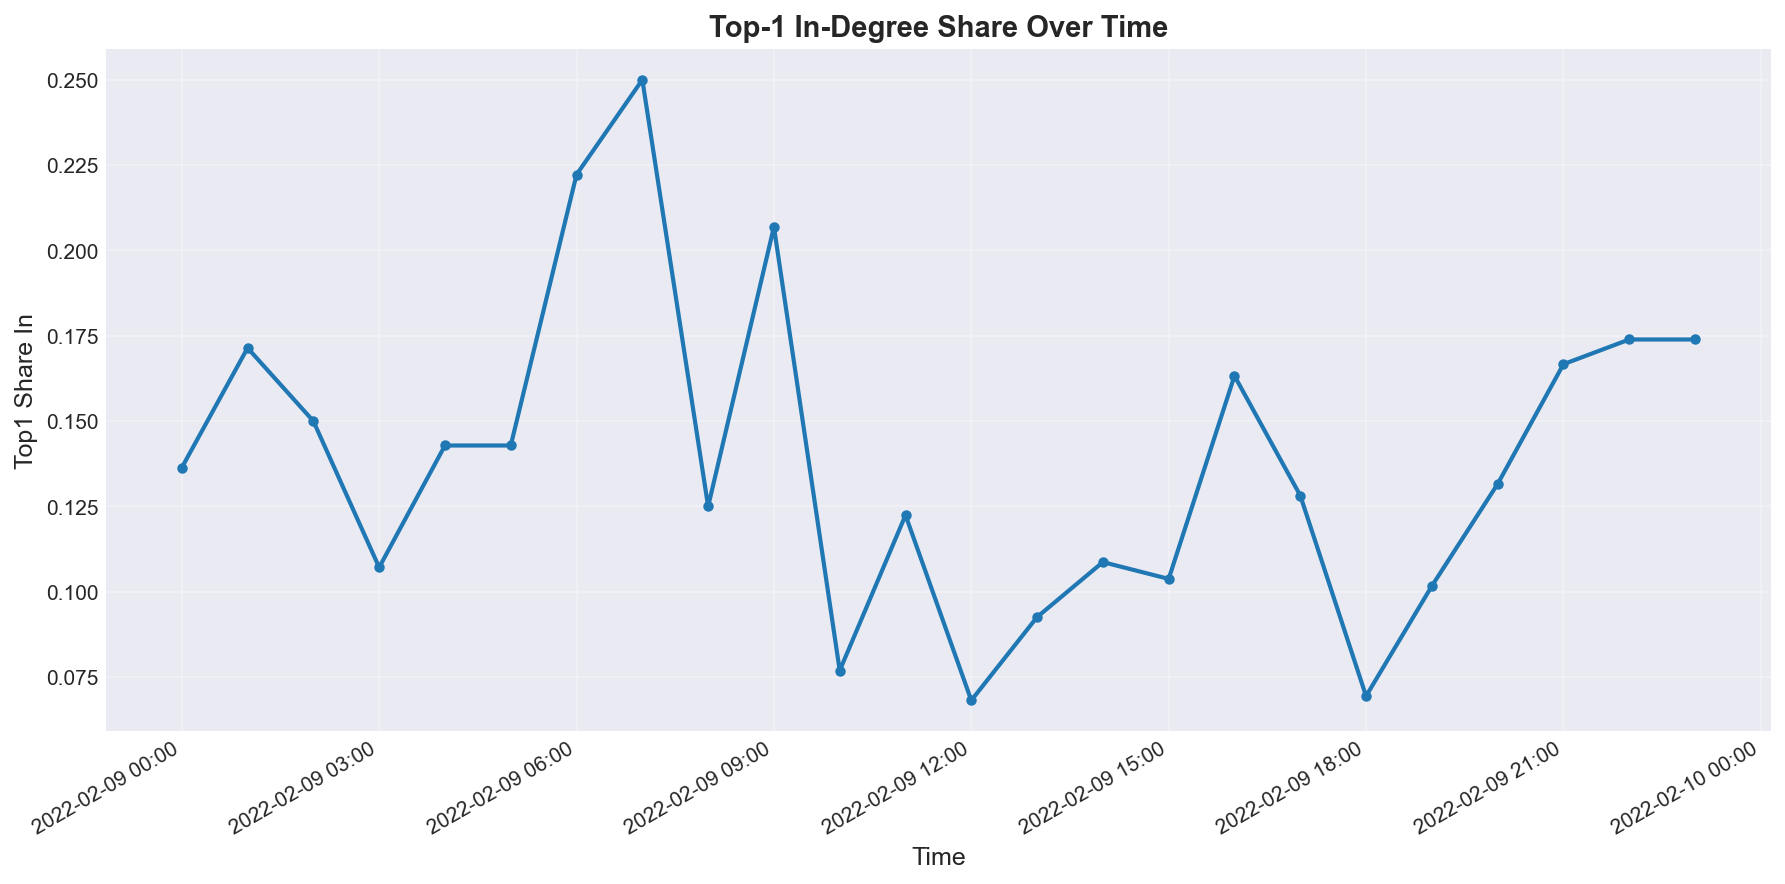

Não encontrado: c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\outputs\h1_monark\windowed\plots\intercommunity_over_time.png


### ego_density_over_time.png

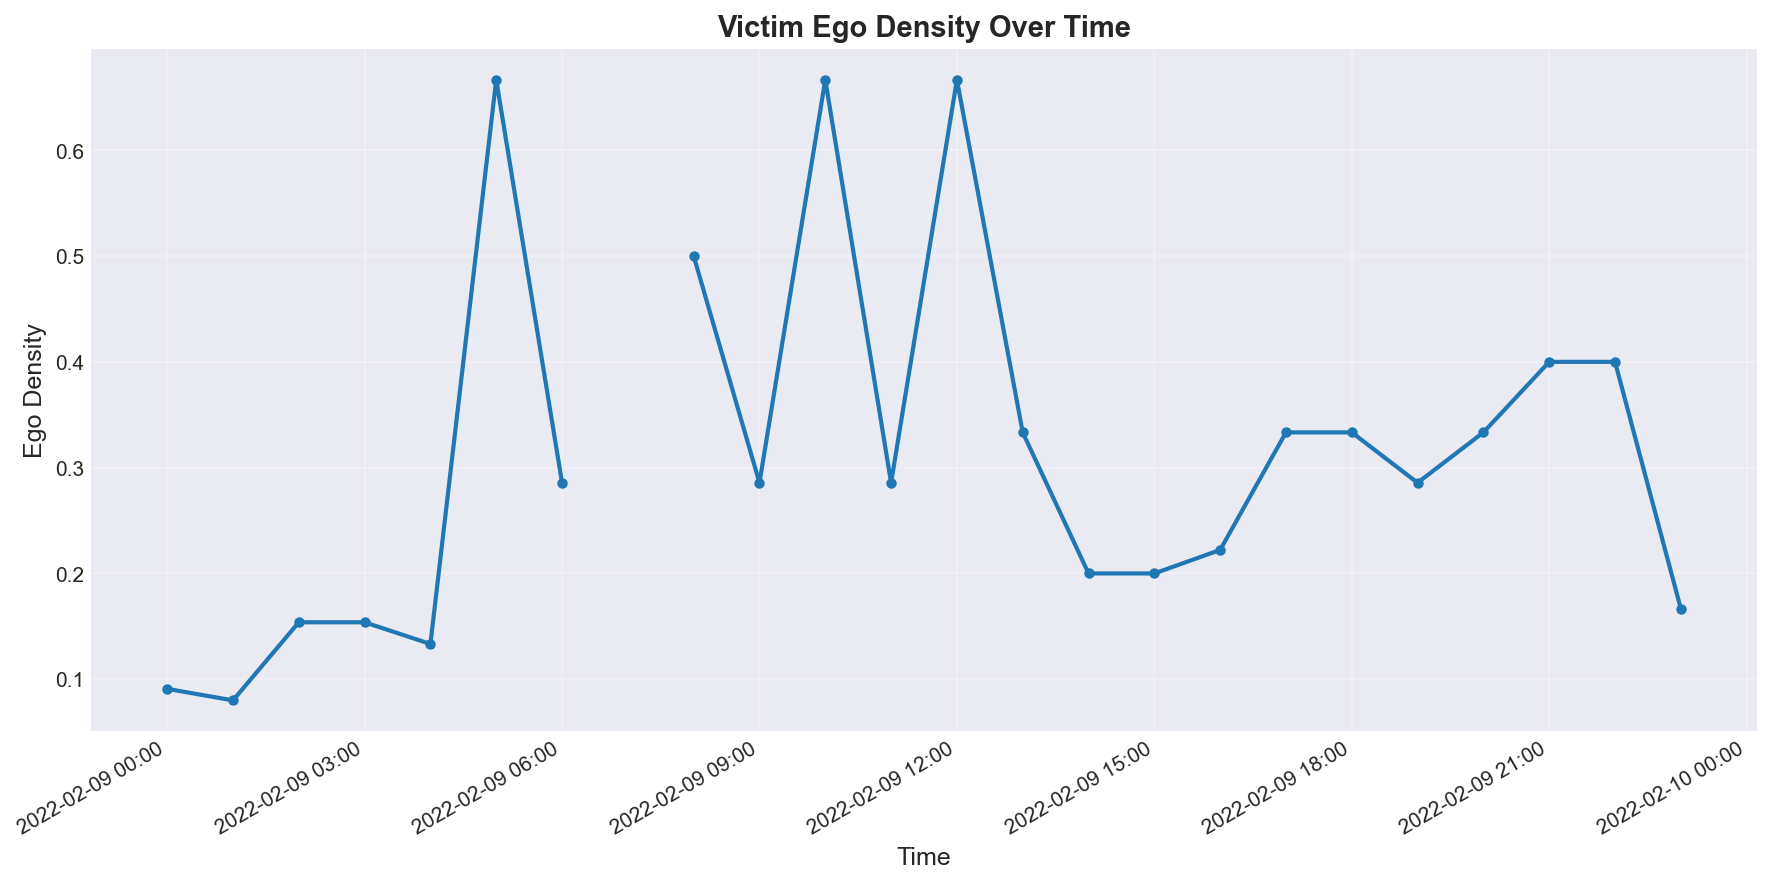

### ego_reciprocity_over_time.png

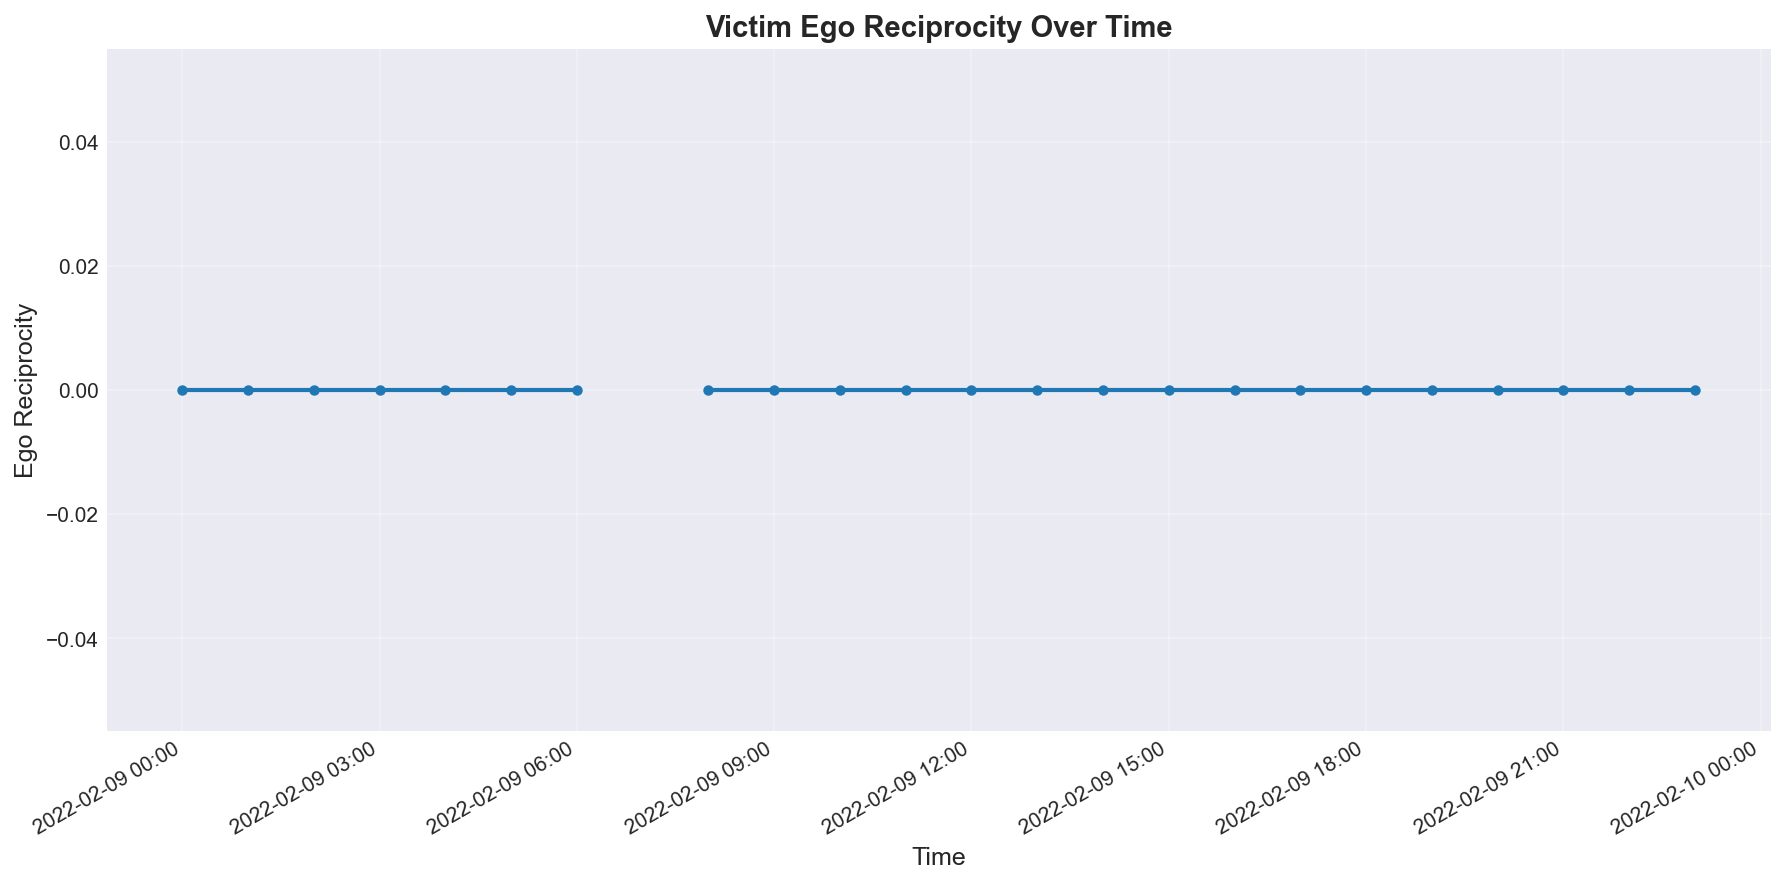

In [73]:
plots_dir = OUT_WINDOWED / "plots"

pngs = [
    "centralization_over_time.png",
    "top1_share_over_time.png",
    "intercommunity_over_time.png",
    "ego_density_over_time.png",
    "ego_reciprocity_over_time.png",
]

for name in pngs:
    path = plots_dir / name
    if path.exists():
        display(Markdown(f"### {name}"))
        display(Image(filename=str(path)))
    else:
        print("Não encontrado:", path)

In [74]:
import networkx as nx

candidate_gexf_dirs = [
    OUT_GEXF,
    REPO_ROOT / "data" / "outputs" / "monark" / "tables",
    REPO_ROOT / "data" / "outputs" / "monark",
]

gexf_files = []
GEXF_DIR = None

for d in candidate_gexf_dirs:
    if d.exists():
        files = sorted(d.rglob("monark_6h_*.gexf"))
        if files:
            gexf_files = files
            GEXF_DIR = d
            break

print("Pasta de GEXF usada:", GEXF_DIR if gexf_files else "nenhuma")
print("Total de GEXF encontrados:", len(gexf_files))
for i, f in enumerate(gexf_files):
    print(i, f.name)


Pasta de GEXF usada: c:\Users\Paes1\NETLOGO\scapegoat_pipeline_gephi\mvp\outputs\h1_monark\gexf
Total de GEXF encontrados: 4
0 monark_6h_2022-02-09_00-00_05-59.gexf
1 monark_6h_2022-02-09_06-00_11-59.gexf
2 monark_6h_2022-02-09_12-00_17-59.gexf
3 monark_6h_2022-02-09_18-00_23-59.gexf


As métricas temporais acima combinam a janela inicial de 3h com as janelas subsequentes de 6h. Os snapshots visuais abaixo usam apenas janelas de 6h para manter comparabilidade entre os grafos.

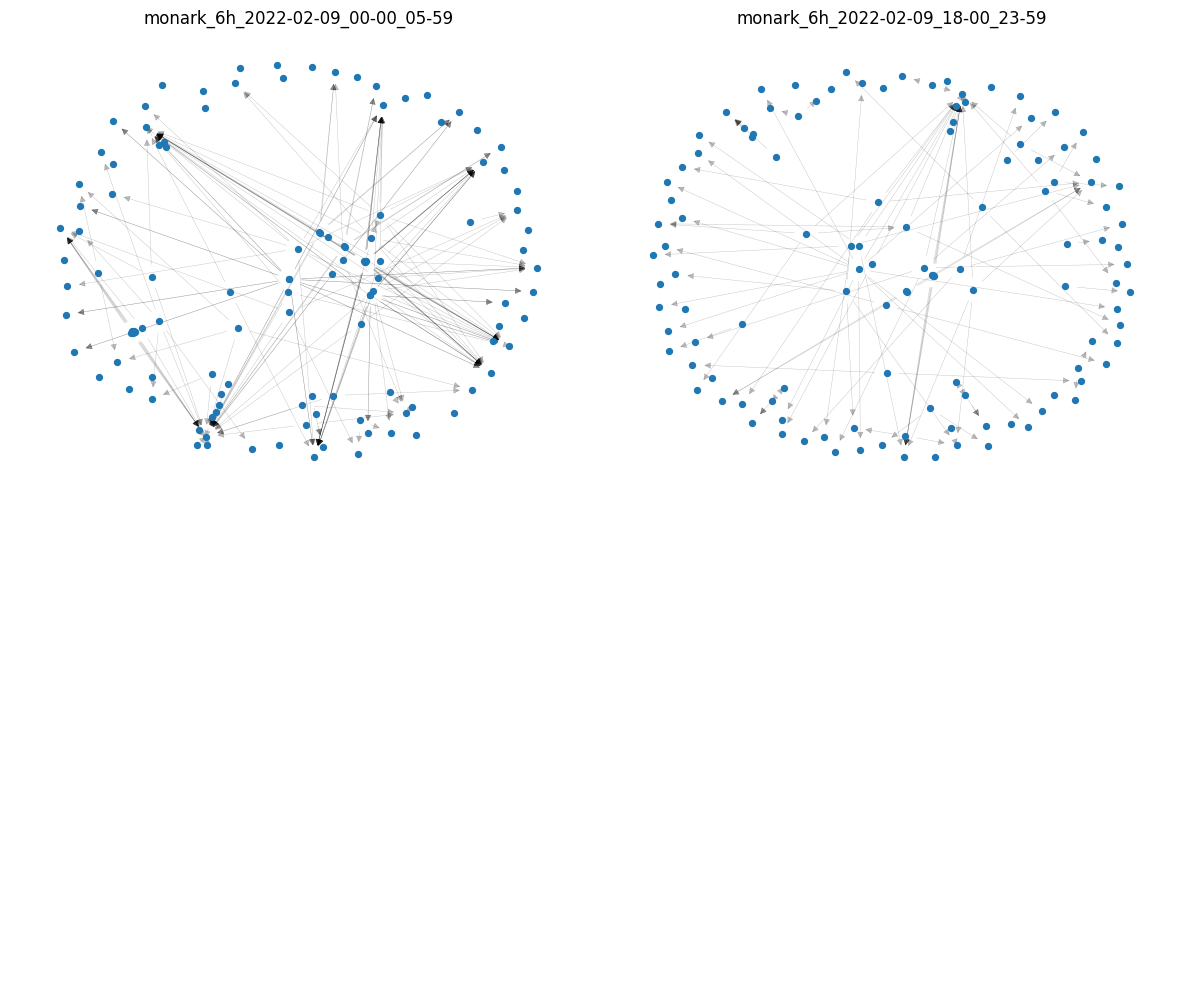

In [75]:
def draw_gexf_snapshot(path, ax, top_n=120):
    G = nx.read_gexf(path)
    degrees = dict(G.degree())
    keep = [n for n, _ in sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:top_n]]
    H = G.subgraph(keep).copy()

    pos = nx.spring_layout(H, seed=42)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_size=18)
    nx.draw_networkx_edges(H, pos, ax=ax, width=0.3, alpha=0.25)
    ax.set_title(path.stem[:50])
    ax.axis("off")

if gexf_files:
    peak_idx_safe = min(peak_idx, len(gexf_files) - 1)
    snapshot_idxs = sorted(set([
        0,
        max(0, peak_idx_safe - 1),
        peak_idx_safe,
        len(gexf_files) - 1
    ]))
    selected_snapshots = [gexf_files[i] for i in snapshot_idxs]
else:
    selected_snapshots = []

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, path in zip(axes, selected_snapshots):
    draw_gexf_snapshot(path, ax)

for ax in axes[len(selected_snapshots):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [77]:
from IPython.display import Markdown, display

def compare_text(summary_df, phase_a, phase_b, col, up_text, down_text):
    a = phase_value(summary_df, phase_a, col)
    b = phase_value(summary_df, phase_b, col)

    if a is None or b is None:
        return "não pôde ser avaliado"
    return up_text if a > b else down_text

conc = compare_text(summary, "climax", "pre", "indeg_centralization", "aumentou", "não aumentou")
share = compare_text(summary, "climax", "pre", "top1_share_in", "subiu", "não subiu")
mod = compare_text(summary, "climax", "pre", "modularity", "não caiu", "caiu")
ego_d = compare_text(summary, "climax", "pre", "ego_density", "não caiu", "caiu")
ego_r = compare_text(summary, "climax", "pre", "ego_reciprocity", "não caiu", "caiu")

nota_pre = ""
if "pre" not in summary.index:
    nota_pre = "\n\n**Observação metodológica:** o recorte não contém uma fase pré-clímax observável; a primeira janela já coincide com o pico."

texto = f"""
## Conclusão provisória

- A centralização {conc} no clímax.
- O top1_share_in {share} no clímax.
- A modularidade {mod} no clímax.
- A ego_density da vítima {ego_d}.
- A ego_reciprocity da vítima {ego_r}.{nota_pre}
"""

display(Markdown(texto))


## Conclusão provisória

- A centralização não pôde ser avaliado no clímax.
- O top1_share_in não pôde ser avaliado no clímax.
- A modularidade não pôde ser avaliado no clímax.
- A ego_density da vítima não pôde ser avaliado.
- A ego_reciprocity da vítima não pôde ser avaliado.

**Observação metodológica:** o recorte não contém uma fase pré-clímax observável; a primeira janela já coincide com o pico.


## Leitura provisória dos resultados

### 1. Intensidade do caso
O pico de atividade ocorreu em ________.

### 2. Concentração
Durante o clímax, `indeg_centralization` ________ e `top1_share_in` ________.
Isso sugere que ______________________________.

### 3. Estrutura comunitária
Durante o clímax, `modularity` ________ e `intercommunity_ratio` ________.
Isso é compatível / incompatível com ______________________________.

### 4. Isolamento da vítima
Durante o clímax, `ego_density` ________ e `ego_reciprocity` ________.
Se houver `avg_dist`, ele ________.
Isso sugere ______________________________.

### 5. Conclusão provisória
A hipótese de convergência vitimária recebeu evidência:
- forte / moderada / fraca

Porque ____________________________________________.